This dataset shows the annual registrations of materials at Toronto Public Library branches.

**Registrations** is defined as a combination of:
- first-time checkouts (i.e. when items are initially borrowed) and
- renewals (i.e. transactions that extend the due dates of borrowed items). 

This data covers the **registrations of physical materials** (e.g. books, CDs, DVDs, etc.) and electronic resources (e.g. ebooks, streaming content, etc.).

The branch associated with a registrations total is the library from which the transactions were processed.

For **online renewals** of physical materials, the registrations is associated with the home branch of the renewing customer.

The VIR (Virtual Library) branch code is used to represent all electronic registrations totals.

# 0. imports

In [1]:
import os
os.chdir("/home/ruchirich/Documents/repositories/toronto-open-data/tpl")
cwd = os.getcwd()
print(cwd)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.max_columns', None)

/home/ruchirich/Documents/repositories/toronto-open-data/tpl


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1275 entries, 0 to 1274
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Year           1275 non-null   object
 1   BranchCode     1275 non-null   object
 2   Registrations  1275 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 30.0+ KB
None
   Year BranchCode  Registrations
0  2012         AB           4939
1  2012        ACD           1695
2  2012         AD            445
3  2012         AG           3166
4  2012         AH            467


<Axes: xlabel='Year'>

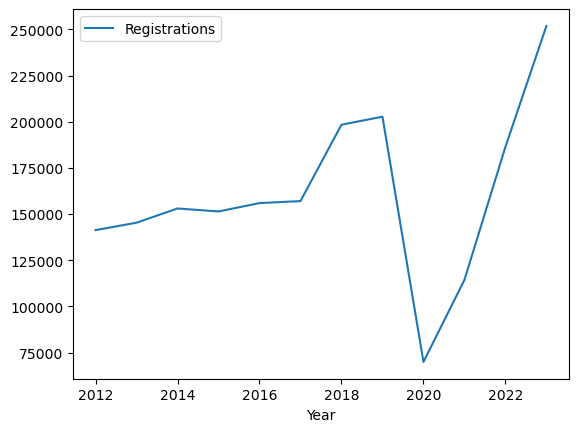

In [2]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-card-registrations"}
registrations_file = cwd+"/data/library-card-registrations.csv"

download_data(params, registrations_file)
usecols = ['Year', 'BranchCode', 'Registrations']
registrations = pd.read_csv(registrations_file, usecols=usecols, parse_dates=["Year"], date_format="%Y")
registrations['Year'] = registrations["Year"].dt.year.astype("object")
print(registrations.info())
print(registrations.head())

# Plot annual registrations at TPL
registrations[['Year', 'Registrations']].groupby('Year').sum().plot.line()

In [3]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "library-branch-general-information"}
branch_info_file = cwd+"/data/library-branch-general-information.csv"

download_data(params, branch_info_file)
# usecols = ["BranchCode", "BranchName", "PhysicalBranch"]
# branch_info = pd.read_csv(branch_info_file, usecols=usecols)
branch_info = pd.read_csv(branch_info_file)
print(branch_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 27 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   _id                   112 non-null    int64  
 1   BranchCode            112 non-null    object 
 2   PhysicalBranch        112 non-null    int64  
 3   BranchName            112 non-null    object 
 4   Address               103 non-null    object 
 5   PostalCode            103 non-null    object 
 6   Website               108 non-null    object 
 7   Telephone             105 non-null    object 
 8   SquareFootage         110 non-null    object 
 9   PublicParking         100 non-null    object 
 10  KidsStop              100 non-null    float64
 11  LeadingReading        100 non-null    float64
 12  CLC                   100 non-null    float64
 13  DIH                   100 non-null    float64
 14  TeenCouncil           100 non-null    float64
 15  YouthHub              1

## 0.1. data

In [4]:
registrations_branch_info = registrations.merge(right=branch_info, indicator=True, left_on="BranchCode", right_on="BranchCode", how="left",validate="m:1")
print(registrations_branch_info.head())

   Year BranchCode  Registrations  _id  PhysicalBranch       BranchName  \
0  2012         AB           4939    1               1           Albion   
1  2012        ACD           1695    2               1  Albert Campbell   
2  2012         AD            445    3               1        Alderwood   
3  2012         AG           3166    4               1        Agincourt   
4  2012         AH            467    5               1   Armour Heights   

                                     Address PostalCode  \
0     1515 Albion Road, Toronto, ON, M9V 1B2    M9V 1B2   
1  496 Birchmount Road, Toronto, ON, M1K 1N8    M1K 1N8   
2      2 Orianna Drive, Toronto, ON, M8W 4Y1    M8W 4Y1   
3     155 Bonis Avenue, Toronto, ON, M1T 3W6    M1T 3W6   
4     2140 Avenue Road, Toronto, ON, M5M 4M7    M5M 4M7   

                             Website     Telephone SquareFootage  \
0          https://www.tpl.ca/albion  416-394-5170         29000   
1  https://www.tpl.ca/albertcampbell  416-396-8890        

In [5]:
data = pd.read_csv("data/data_binary_classification.csv")

data["Registrations"] = registrations_branch_info["Registrations"]

data.to_csv(path_or_buf="data/data_binary_classification.csv", index=False)

# 1. PhysicalBranch (Online vs. Physical)

In [6]:
registrations_by_physical_branch = registrations_branch_info[["Year", "PhysicalBranch", "Registrations"]].pivot_table(index="Year", columns="PhysicalBranch", values="Registrations", aggfunc="sum")
registrations_by_physical_branch

PhysicalBranch,0,1
Year,,
2012,625,140685
2013,610,144733
2014,660,152381
2015,520,150897
2016,534,155416
2017,514,156536
2018,483,197922
2019,430,202302
2020,6677,63269


In [7]:
registrations_by_physical_branch_melted = registrations_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Registrations")

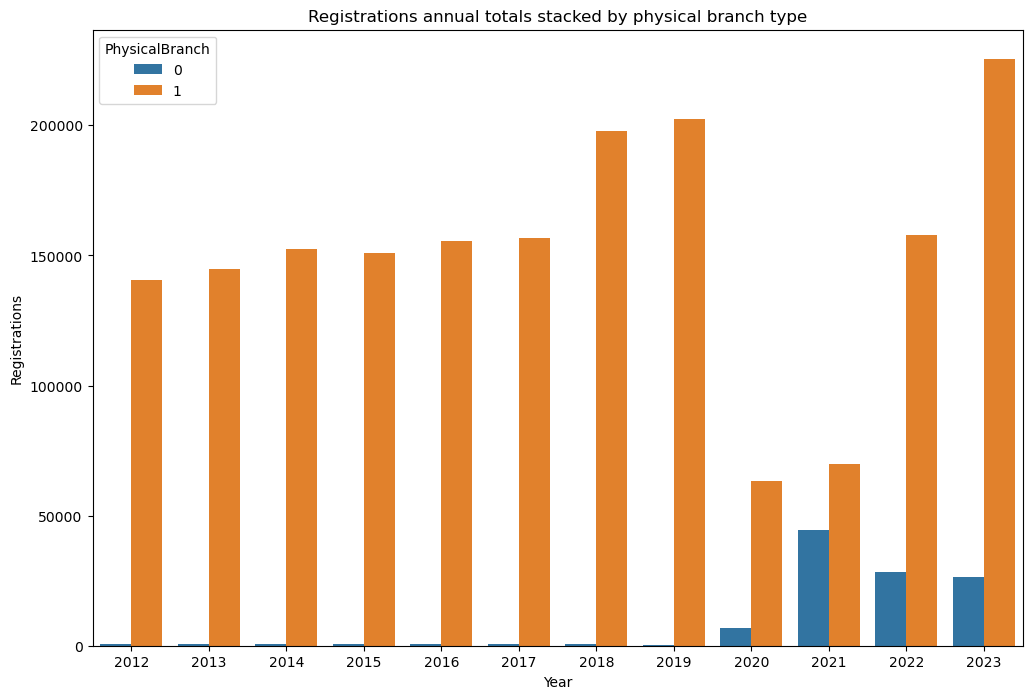

In [8]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=registrations_by_physical_branch_melted,
    x="Year",
    y="Registrations",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Registrations annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="Registrations",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/annual_registrations_by_physical_branch_indicator.png")

In [9]:
registrations_by_physical_branch_pct = registrations_by_physical_branch.copy(deep=True)
registrations_by_physical_branch_pct[0] = registrations_by_physical_branch_pct[0] / (registrations_by_physical_branch_pct[0] + registrations_by_physical_branch_pct[1]) * 100
registrations_by_physical_branch_pct[1] = registrations_by_physical_branch_pct[1] / (registrations_by_physical_branch[0] + registrations_by_physical_branch_pct[1]) * 100
print(registrations_by_physical_branch_pct)

PhysicalBranch          0          1
Year                                
2012             0.442290  99.557710
2013             0.419697  99.580303
2014             0.431257  99.568743
2015             0.343422  99.656578
2016             0.342417  99.657583
2017             0.327284  99.672716
2018             0.243441  99.756559
2019             0.212103  99.787897
2020             9.545935  90.454065
2021            38.831429  61.168571
2022            15.278530  84.721470
2023            10.490649  89.509351


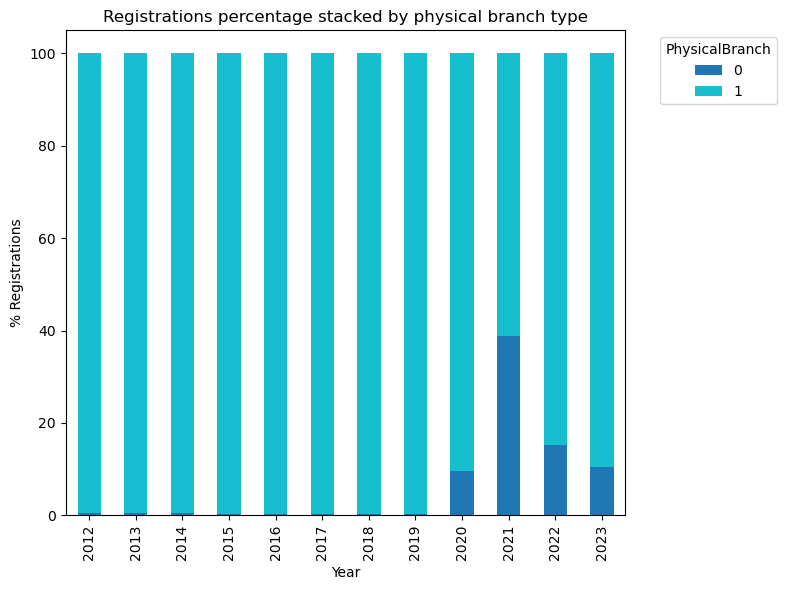

In [10]:
# Create stacked bar chart
fig, ax = plt.subplots(figsize=(8, 6))
registrations_by_physical_branch_pct.plot(kind='bar', stacked=True, ax=ax, colormap='tab10')

ax.set(
    title="Registrations percentage stacked by physical branch type",
    xlabel="Year",
    ylabel="% Registrations",
)
ax.legend(title='PhysicalBranch', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()
fig.savefig(fname="output/annual_percentage_registrations_by_physical_branch_indicator.png")

## Log Scale Plot

In [11]:
registrations_by_physical_branch = registrations_branch_info[["Year", "PhysicalBranch", "Registrations"]].pivot_table(index="Year", columns="PhysicalBranch", values="Registrations", aggfunc="sum")
print(registrations_by_physical_branch)
registrations_by_physical_branch[0] = np.log10(registrations_by_physical_branch[0])
registrations_by_physical_branch[1] = np.log10(registrations_by_physical_branch[1])
print(registrations_by_physical_branch)
registrations_by_physical_branch_melted = registrations_by_physical_branch.reset_index().melt(id_vars="Year", var_name="PhysicalBranch", value_name="Registrations")

PhysicalBranch      0       1
Year                         
2012              625  140685
2013              610  144733
2014              660  152381
2015              520  150897
2016              534  155416
2017              514  156536
2018              483  197922
2019              430  202302
2020             6677   63269
2021            44415   69964
2022            28483  157942
2023            26425  225466
PhysicalBranch         0         1
Year                              
2012            2.795880  5.148248
2013            2.785330  5.160568
2014            2.819544  5.182931
2015            2.716003  5.178681
2016            2.727541  5.191496
2017            2.710963  5.194614
2018            2.683947  5.296494
2019            2.633468  5.306000
2020            3.824581  4.801191
2021            4.647530  4.844875
2022            4.454586  5.198498
2023            4.422015  5.353081


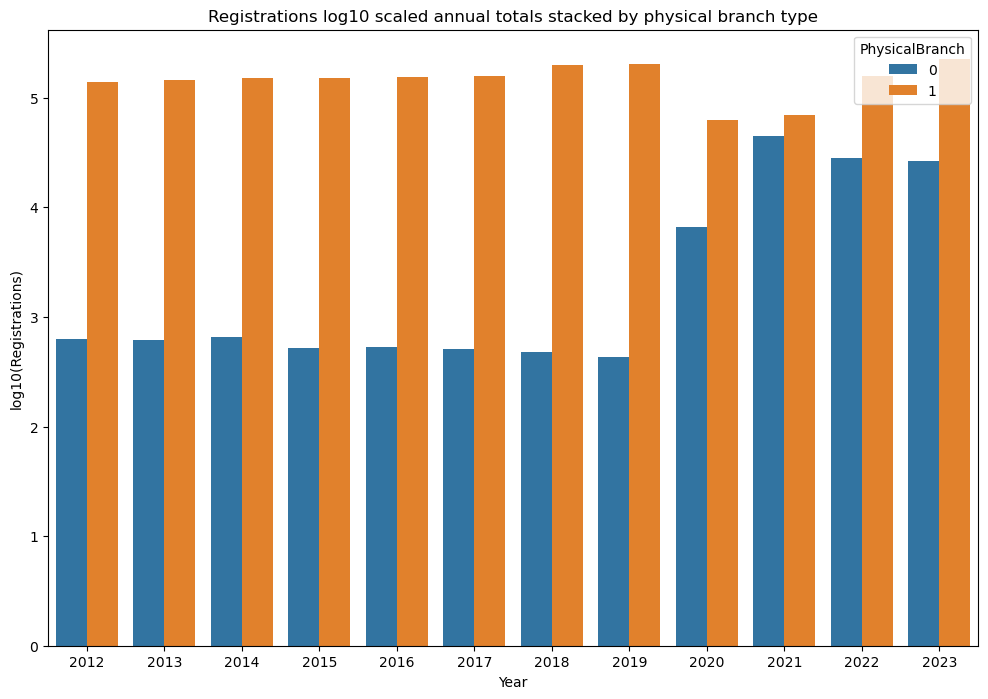

In [12]:
fig = plt.figure(1, figsize=(12, 8))
ax = fig.add_subplot(111)

plot = sns.barplot(
    data=registrations_by_physical_branch_melted,
    x="Year",
    y="Registrations",
    hue="PhysicalBranch",
    dodge=True,
    ax=ax,
    palette="tab10",
    errorbar=None
)

ax.set(
    title="Registrations log10 scaled annual totals stacked by physical branch type",
    xlabel="Year",
    ylabel="log10(Registrations)",
)
# ax.xaxis.set_ticklabels([])
# ax.yaxis.set_ticklabels([])

# for container in ax.containers:
#     ax.bar_label(container=container, labels=)


plt.show()
fig.savefig(fname="output/log_annual_registrations_by_physical_branch_indicator.png")


## 1.0 Online Branch drilldown

In [13]:
online_registrations = registrations_branch_info[registrations_branch_info['PhysicalBranch'] == 0]
print(online_registrations.head())

    Year BranchCode  Registrations  _id  PhysicalBranch            BranchName  \
5   2012         AL              1    6               0            Answerline   
13  2012      BKONE            143   14               0        Bookmobile One   
14  2012      BKTWO            110   15               0        Bookmobile Two   
30  2012         DS             70   31               0    Departmental Staff   
47  2012        HLS            143   49               0  Home Library Service   

   Address PostalCode                                  Website     Telephone  \
5      NaN        NaN               https://www.tpl.ca/contact  416-397-5981   
13     NaN        NaN           https://www.tpl.ca/bookmobiles           NaN   
14     NaN        NaN           https://www.tpl.ca/bookmobiles           NaN   
30     NaN        NaN                                      NaN           NaN   
47     NaN        NaN  https://www.tpl.ca/home-library-service  416-395-5557   

   SquareFootage PublicParking  

In [14]:
branch_stats = online_registrations.groupby(by='BranchCode').Registrations.describe()
branch_stats.sort_values(by='max', ascending=False)

,count,mean,std,min,25%,50%,75%,max
BranchCode,,,,,,,,
VIR,4.0,26268.750000,15470.281410,6511.0,21169.00,27152.5,32252.25,44259.0
HLS,12.0,147.250000,87.517401,37.0,50.75,156.5,218.50,283.0
BKONE,12.0,123.250000,61.354595,48.0,82.75,114.0,140.00,279.0
SB,12.0,102.000000,42.975680,24.0,77.75,117.5,132.25,157.0
BKTWO,10.0,38.900000,42.979194,2.0,16.25,22.5,35.00,125.0
DS,12.0,29.416667,25.371632,1.0,11.50,22.0,35.75,85.0
OS,3.0,24.333333,40.414519,1.0,1.00,1.0,36.00,71.0
LD,5.0,1.200000,0.447214,1.0,1.00,1.0,1.00,2.0
AL,8.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0


## 1.1 Library Collections branches

Osborne and Merill Collections at Lilian H.Smith branch

In [15]:
branch_info[branch_info['BranchCode'] == 'OS']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
75,76,OS,0,Osborne Collection,"239 College Street, 4th floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/osborne,416-393-7753,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.65785,-79.39864,NaN,NaN,NaN,NaN,NaN,NaN


In [16]:
branch_info[branch_info['BranchCode'] == 'ME']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
67,68,ME,0,Merril Collection,"239 College Street, 3rd floor, Toronto, ON, M5...",M5T 1R5,https://www.tpl.ca/merril,416-393-7748,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,RR,43.657222,-79.398333,NaN,NaN,NaN,NaN,NaN,NaN


## 1.3 Sunnybrook

The service provided supports the Sunnybrook community - its hospital patients, veterans and staff.

In [17]:
branch_info[branch_info['BranchCode'] == 'SB']

,_id,BranchCode,PhysicalBranch,BranchName,Address,PostalCode,Website,Telephone,SquareFootage,PublicParking,KidsStop,LeadingReading,CLC,DIH,TeenCouncil,YouthHub,AdultLiteracyProgram,Workstations,ServiceTier,Lat,Long,NBHDNo,NBHDName,TPLNIA,WardNo,WardName,PresentSiteYear
91,92,SB,0,Sunnybrook Hospital,"2075 Bayview Avenue, Aging and Veterans Care, ...",M4N 3M5,https://www.tpl.ca/hospital-service,416-480-6100 EXT 62624,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NL,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: xlabel='Year', ylabel='Registrations'>

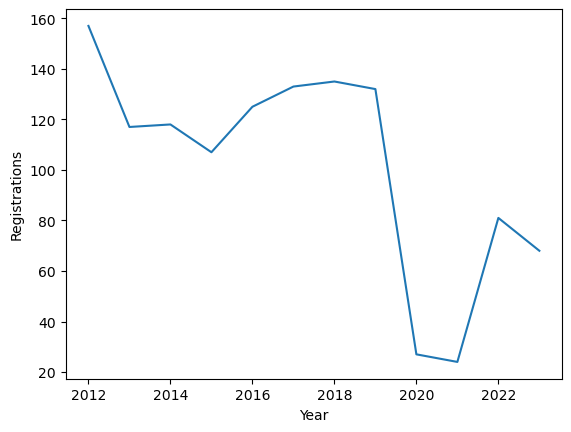

In [18]:
Sunnybrook = online_registrations[online_registrations['BranchCode'] == 'SB']

sns.lineplot(data=Sunnybrook, x='Year', y='Registrations')

# APPENDIX

## A.1 Correlation plot

Correlation of `Registrations` in `BranchCode` feature

In [ ]:
from sklearn.impute import SimpleImputer
registrations_by_branch = registrations.pivot(columns='BranchCode',index='Year',values='Registrations')
registrations_by_branch_imputed = registrations_by_branch.copy(deep=True)

imputation_strategies = {"median": ["BKTWO"],
                        "most_frequent": ["AL", "LD", "ME", "OS"],
                        "constant": ["VIR", "FO", "SC"]}

for strategy, columns in imputation_strategies.items():
    cols_to_impute = [col for col in columns if col in registrations_by_branch_imputed.columns]

    if strategy == "constant":
        imputer = SimpleImputer(missing_values=pd.NA, strategy=strategy, fill_value=0)
    else:
        imputer = SimpleImputer(missing_values=pd.NA, strategy=strategy)
    
    registrations_by_branch_imputed[cols_to_impute] = imputer.fit_transform(registrations_by_branch_imputed[cols_to_impute])

registrations_correlation = registrations_by_branch_imputed.corr()
registrations_by_branch_imputed

In [51]:
registrations_correlation

BranchCode,AB,ACD,AD,AG,AH,AL,AN,AP,BB,BC,BD,BE,BF,BKONE,BKTWO,BL,BR,BRW,BUR,CC,CE,CED,CH,CL,CS,DA,DM,DO,DP,DR,DS,DT,DU,EA,EB,EG,EN,ES,FH,FO,FP,FV,GE,GHP,GW,HB,HC,HIL,HLS,HP,HS,HW,JD,JO,JS,KE,LB,LD,LE,LO,LS,MA,MAL,MAS,MCG,MD,ME,MI,MP,MRV,MS,ND,NE,NT,OS,OV,PA,PE,PK,PL,PM,PU,PV,QS,RD,RI,RN,RX,SA,SB,SC,SI,SJ,SL,SP,ST,SW,SWS,TA,TH,TOD,TRL,VIR,VV,WE,WP,WS,WY,YO,YW
BranchCode,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
AB,1.000000,0.714038,0.823775,0.768587,0.784689,NaN,0.966659,0.629283,0.862203,0.838309,0.761173,0.882283,0.935406,0.083206,0.056626,0.888712,0.785925,0.871761,0.808404,0.737947,0.941192,0.786535,0.880050,0.556173,0.897229,0.890529,0.824718,0.837918,0.898402,0.804704,0.204096,0.894846,0.886624,0.872602,0.815490,0.792238,0.909167,0.835253,0.862248,0.740550,0.687945,0.729149,0.942343,0.802100,0.684250,0.895244,0.833302,0.696506,0.175234,0.883892,0.696968,0.879106,0.596106,0.855402,0.792051,0.730533,0.767506,0.300751,0.896375,0.918983,0.800274,0.934189,0.884528,0.725263,0.865742,0.610983,NaN,0.890840,0.709276,0.715336,0.794052,0.918261,0.936583,0.833606,0.352210,0.849952,0.911058,0.903276,0.803158,0.649130,0.883496,0.900337,0.529975,0.900346,0.884711,0.896250,0.780767,0.795413,0.888734,0.600654,0.794906,0.147594,0.880518,0.816841,0.910162,0.757262,0.851221,0.903578,0.784432,0.742045,0.856616,0.883370,-0.294206,0.882607,0.874748,0.814043,0.817208,0.407680,0.918446,0.767368
ACD,0.714038,1.000000,0.840508,0.882690,0.448483,NaN,0.782576,0.815510,0.524088,0.525213,0.919067,0.875374,0.767488,0.408901,0.300627,0.716966,0.691840,0.861588,0.936735,0.807588,0.881769,0.735704,0.718047,0.719272,0.823016,0.835974,0.906096,0.942242,0.761594,0.881376,0.361116,0.632929,0.698343,0.821882,0.870174,0.750981,0.875793,0.604862,0.873042,0.887719,0.925959,0.445135,0.783085,0.983219,0.916810,0.863507,0.840783,0.830278,0.199124,0.700326,0.752941,0.890543,0.733457,0.833561,0.817236,0.934246,0.885932,0.050067,0.812632,0.812846,0.955539,0.838910,0.899630,0.858591,0.929198,0.589998,NaN,0.886030,0.587679,0.893643,0.844005,0.787606,0.852057,0.888399,0.653222,0.599950,0.810193,0.664257,0.868137,0.887301,0.705464,0.894628,0.832978,0.831020,0.687300,0.879288,0.699214,0.947229,0.649283,0.494929,0.946422,0.605061,0.916715,0.618112,0.843008,0.766437,0.672468,0.795273,0.774891,0.788209,0.861303,0.782014,-0.174394,0.872632,0.835132,0.776501,0.887486,0.874346,0.840278,0.749189
AD,0.823775,0.840508,1.000000,0.814528,0.550120,NaN,0.843085,0.805370,0.774850,0.668077,0.938154,0.901626,0.851238,0.209603,-0.060606,0.772869,0.855421,0.972675,0.889820,0.920564,0.905783,0.642466,0.777390,0.702617,0.902367,0.940699,0.874724,0.919270,0.850897,0.767770,0.147986,0.809896,0.858790,0.886492,0.980756,0.794320,0.906826,0.853456,0.857352,0.937449,0.805741,0.680700,0.850814,0.911441,0.884934,0.901535,0.933696,0.693330,-0.031187,0.846499,0.730344,0.947845,0.566068,0.947015,0.906089,0.913977,0.931594,-0.022098,0.985408,0.814384,0.900453,0.949781,0.931739,0.702243,0.933571,0.737387,NaN,0.950914,0.469898,0.906945,0.956884,0.953222,0.845466,0.928049,0.606127,0.816392,0.873871,0.921163,0.931309,0.771710,0.888144,0.904027,0.631063,0.952022,0.823335,0.924493,0.850518,0.886735,0.773462,0.320766,0.927317,0.511369,0.916176,0.887017,0.904758,0.844116,0.729733,0.897830,0.852431,0.704957,0.847613,0.804168,0.091209,0.898257,0.911974,0.749353,0.804216,0.638354,0.866521,0.578354
AG,0.768587,0.882690,0.814528,1.000000,0.651460,NaN,0.767243,0.901838,0.730638,0.733562,0.868889,0.899454,0.865808,0.569515,0.419262,0.822623,0.719805,0.882559,0.928660,0.762064,0.895379,0.898080,0.745066,0.844090,0.842372,0.874129,0.904338,0.905503,0.890945,0.896895,0.124393,0.773536,0.861145,0.841475,0.816276,0.837041,0.866608,0.794660,0.929216,0.823056,0.912641,0.436153,0.783550,0.891879,0.793035,0.886076,0.848036,0.907522,0.214149,0.787185,0.927160,0.837224,0.884568,0.803904,0.835679,0.814112,0.845493,-0.099958,0.813372,0.830499,0.921574,0.840262,0.935

<Figure size 800x600 with 0 Axes>

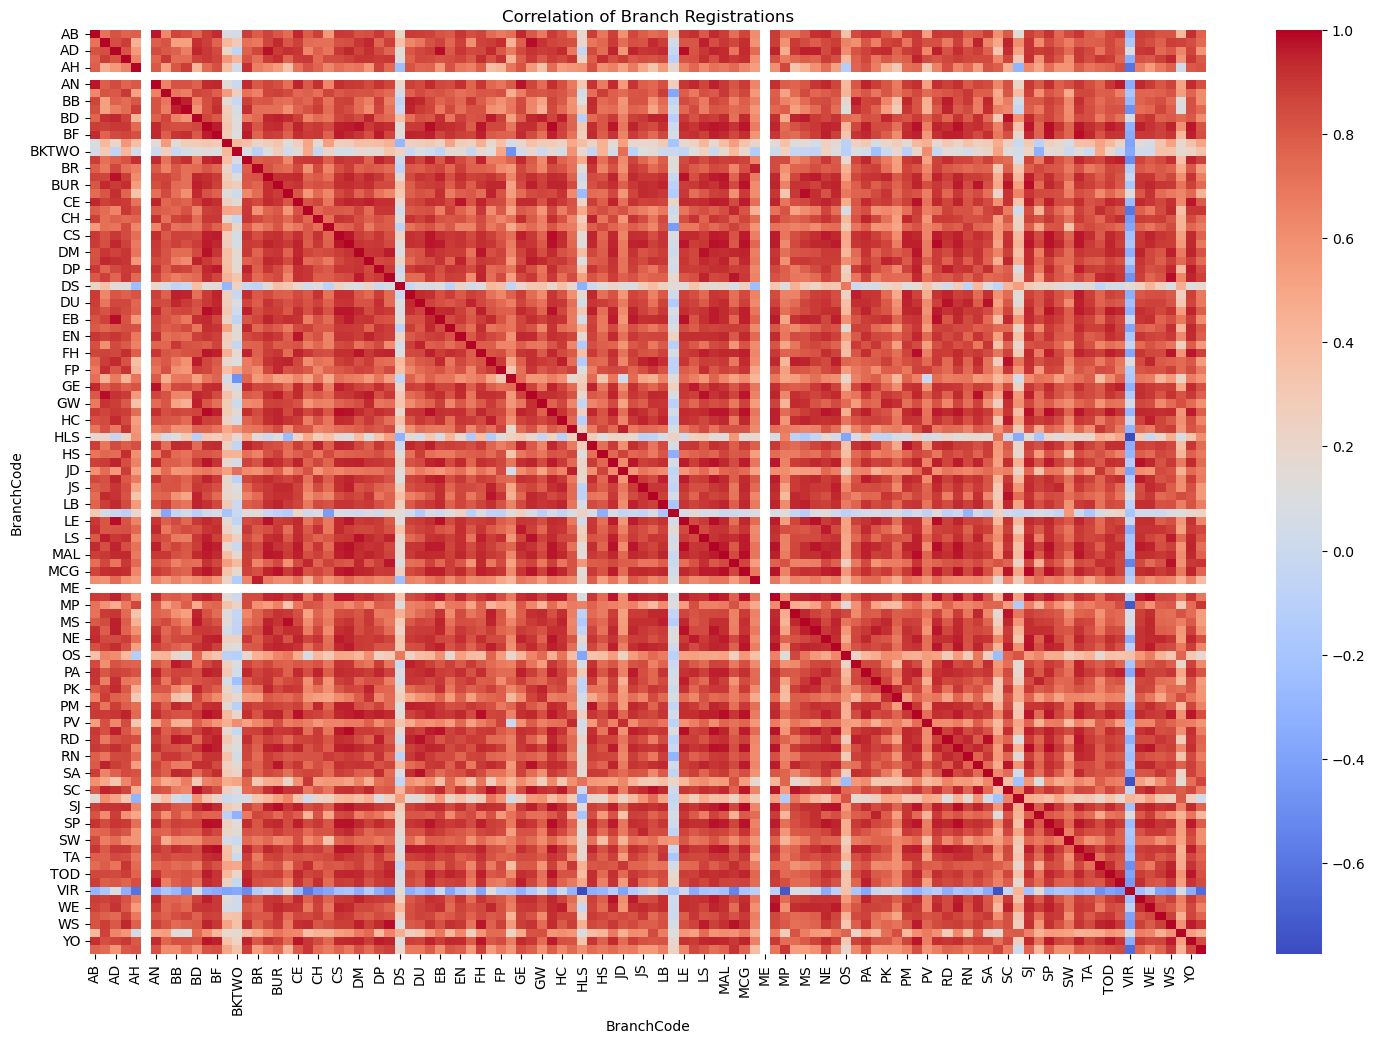

In [50]:
fig = plt.figure(1, figsize=(8, 6))
# ax = fig.add_subplot(111)

plt.figure(figsize=(18,12))
heatmap = sns.heatmap(data=registrations_correlation,cmap='coolwarm')

heatmap.set(
    title="Correlation of Branch Registrations",
    xlabel="BranchCode",
    ylabel="BranchCode",
)
# heatmap.xaxis.set_ticklabels([])
# heatmap.yaxis.set_ticklabels([])

# plt.show()
fig.savefig(fname="output/Branch_Registrations_Correlation.png")

## A.2 PCA

Single Valued Decomposition of `BranchCode` feature across `Year` dimensions

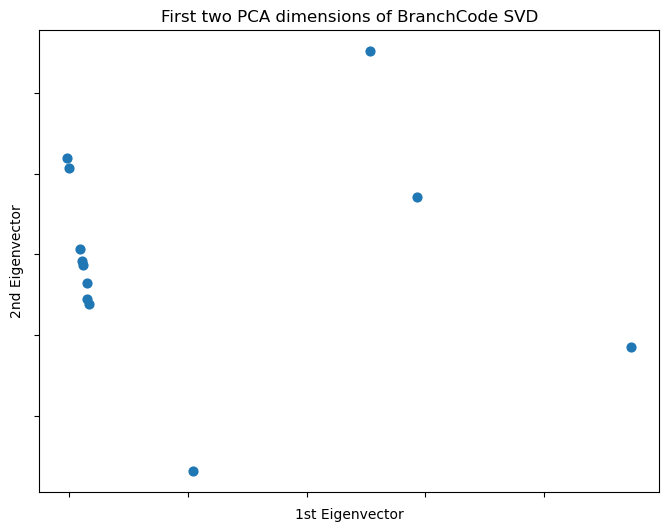

In [52]:
from sklearn.decomposition import PCA

fig = plt.figure(1, figsize=(8, 6))
ax = fig.add_subplot(111)
X_reduced = PCA(n_components=2).fit_transform(registrations_by_branch_imputed)
scatter = ax.scatter(
    X_reduced[:, 0],
    X_reduced[:, 1],
    s=40,
)

ax.set(
    title="First two PCA dimensions of BranchCode SVD",
    xlabel="1st Eigenvector",
    ylabel="2nd Eigenvector",
)
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])

plt.show()
fig.savefig(fname="output/PCA_Registrations_2D.png")

In [53]:
X_reduced

array([[ -8321.84270615,  -3084.3649557 ],
       [ -8470.37161153,  -2753.04649751],
       [ -8868.35754295,   -687.12009405],
       [ -8944.87996122,   -406.1450668 ],
       [ -9118.25751981,    318.54851705],
       [ -8527.94554707,  -1743.39373343],
       [ -9990.42575201,   5320.56334299],
       [-10137.59008652,   5985.98313998],
       [   409.81389944, -13393.2243446 ],
       [ 37313.44853288,  -5727.17900049],
       [ 19301.89445667,   3566.48759065],
       [ 15354.51383827,  12602.89110191]])

In [54]:
X_reduced.shape

(12, 2)